# Synthetic Data EDA — AnyMatch fine-tuning corpus (v3)

Thorough exploratory analysis of `synthetic_train_v{V}.csv` / `synthetic_test_v{V}.csv` before fine-tuning.
It checks that the generated corpus matches the design in `synthetic_data_generation/Synthetic-Dataset-Spec.md`
and the real-data statistics in `synthetic_data_stats.json`.

**What this notebook verifies**
1. Label balance / prevalence
2. Scenario (`case_type`) coverage — every named case present, in both files
3. Field presence (missingness) vs measured real marginals (±3pp)
4. Value distributions vs real (state, sex, DOB decades, email, SSN bands)
5. **Positives** — anchor survival (the v0.6 invariant) + difficulty spread
6. **Negatives** — hardness (shared-key count) + label integrity (no match/non-match contradiction)
7. Name-coupling token-set invariance
8. Entity disjointness + duplicate-pair leakage
9. The exact **mode4 prompt** the model will see
10. A pass/fail summary dashboard

Run top-to-bottom. Set `V` in the first cell if you generated a different version.

## 0. Setup

In [1]:
# Run from the AnyMatch/ directory (relative imports of utils/, and data/ paths).
import os, sys, json, ast, math
from collections import Counter
# Resolve the AnyMatch repo root (loo.py lives there) so this notebook works whether it is
# opened from the repo root OR from synthetic_data_generation/. Walk up until loo.py is found.
_d = os.getcwd()
for _ in range(4):
    if os.path.exists(os.path.join(_d, 'loo.py')):
        break
    _d = os.path.dirname(_d)
assert os.path.exists(os.path.join(_d, 'loo.py')), f'could not locate AnyMatch root from cwd={os.getcwd()}'
if _d != os.getcwd():
    os.chdir(_d)
    print('chdir ->', _d)
if _d not in sys.path:
    sys.path.insert(0, _d)

import pandas as pd
import numpy as np

# matplotlib is optional — install on Colab if absent. All numeric checks still
# print even if plotting is unavailable.
try:
    import matplotlib.pyplot as plt
    HAVE_PLT = True
except ImportError:
    HAVE_PLT = False
    print('matplotlib not installed — run `pip install matplotlib` for charts; tables still print.')

pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 160)

V = 3  # dataset version
TRAIN_CSV = f'data/synthetic/synthetic_train_v{V}.csv'
TEST_CSV  = f'data/synthetic/synthetic_test_v{V}.csv'
STATS_JSON = 'synthetic_data_generation/synthetic_data_stats.json'
print('files:', TRAIN_CSV, TEST_CSV)

chdir -> /Users/miguelroca/Documents/UChicago/Capstone Project/AnyMatch


files: data/synthetic/synthetic_train_v3.csv data/synthetic/synthetic_test_v3.csv


In [2]:
from utils.alliance_schema import id_str_dtypes, prep_paired_df, CANONICAL_RENAMES
from utils.data_utils import df_serializer

def load_pairs(path):
    # peek header to build the ID-as-string dtype map, then read keeping '' for missing
    header = pd.read_csv(path, nrows=0).columns
    df = pd.read_csv(path, dtype={**id_str_dtypes(header)}, keep_default_na=False, na_values=[])
    df['label'] = df['label'].astype(int)
    return df

train = load_pairs(TRAIN_CSV)
test  = load_pairs(TEST_CSV)
stats = json.load(open(STATS_JSON))
print('train', train.shape, '| test', test.shape)

# The 15 model-input fields (technical column base names), in prompt order.
MODEL_BASES = list(CANONICAL_RENAMES.keys())

def present(s):
    """Boolean mask: value is non-empty (synthetic uses '' for missing)."""
    return s.fillna('').astype(str).str.len() > 0

def both_eq(df, base):
    """present on both sides AND equal."""
    l, r = df[f'{base}_l'].fillna('').astype(str), df[f'{base}_r'].fillna('').astype(str)
    return (l.str.len() > 0) & (l == r)

def phone_overlap(df):
    def ov(row):
        a = set(str(row['Phones_set_l']).split()); b = set(str(row['Phones_set_r']).split())
        a.discard(''); b.discard('')
        return len(a & b) > 0
    return df.apply(ov, axis=1)

def barh(series, title, real=None, top=None):
    """Horizontal bar of a value->pct series; optionally overlay a real-data series."""
    if not HAVE_PLT:
        print(title); print(series.round(3).to_string()); return
    s = series if top is None else series.head(top)
    fig, ax = plt.subplots(figsize=(7, max(2, 0.35*len(s))))
    idx = list(range(len(s)))
    if real is not None:
        ax.barh([i+0.2 for i in idx], s.values, height=0.4, label='synthetic')
        rv = [real.get(k, 0) for k in s.index]
        ax.barh([i-0.2 for i in idx], rv, height=0.4, label='real', alpha=0.7)
        ax.legend()
    else:
        ax.barh(idx, s.values)
    ax.set_yticks(idx); ax.set_yticklabels(s.index); ax.invert_yaxis()
    ax.set_title(title); plt.tight_layout(); plt.show()

train (40000, 49) | test (10000, 49)


## 1. Overview — label balance & prevalence

Train should be ~1:1.5 match:non-match (40% positive). Test is the honest evaluator at ~1:4 (20% positive).

In [3]:
def overview(df, name):
    n = len(df); m = int(df.label.sum())
    print(f'{name:6s} {n:6d} pairs | match {m:5d} ({m/n:.1%}) | non-match {n-m:5d} ({1-m/n:.1%})')
    print(f'       distinct entities: A+B = {pd.concat([df.entity_id_a, df.entity_id_b]).nunique()}')
overview(train, 'TRAIN'); overview(test, 'TEST')

TRAIN   40000 pairs | match 16000 (40.0%) | non-match 24000 (60.0%)
       distinct entities: A+B = 64000
TEST    10000 pairs | match  2000 (20.0%) | non-match  8000 (80.0%)
       distinct entities: A+B = 18000


## 2. Scenario coverage (`case_type`)

Every named scenario in the spec should appear, in **both** train and test (the test mirrors train's difficulty),
and `NM-HARD-*` combinatorial negatives should dominate the negative budget. Bucket-level first, then full table.

In [4]:
def bucket(ct):
    import re
    m = re.match(r'(M|NM|POL)-[A-Z0-9]+', ct)
    # collapse NM-HARD-<keys> into one bucket
    if ct.startswith('NM-HARD'): return 'NM-HARD'
    return m.group(0) if m else ct

for name, df in [('TRAIN', train), ('TEST', test)]:
    print(f'\n=== {name} buckets ===')
    b = df['case_type'].map(bucket).value_counts()
    print(b.to_string())


=== TRAIN buckets ===
case_type
NM-HARD      15132
M-NAME        5899
NM-HH         2176
M-ADDR        2079
NM-COMMON     1904
M-L4          1800
NM-SSN        1629
M-NOSSN       1388
NM-IDF        1355
M-SSN         1136
NM-EASY        720
M-PHONE        692
M-MIX          692
M-EMAIL        692
NM-BND         542
NM-PED         542
M-SEX          346
M-ZIP          346
M-PED          346
POL-AMBIG      320
M-DOB          264

=== TEST buckets ===
case_type
NM-HARD      5200
NM-HH         751
M-NAME        739
NM-COMMON     654
NM-SSN        558
NM-IDF        465
M-ADDR        258
M-L4          225
NM-PED        186
NM-BND        186
M-NOSSN       176
M-SSN         143
M-EMAIL        86
M-MIX          86
M-PHONE        86
M-SEX          43
M-PED          43
M-ZIP          43
POL-AMBIG      40
M-DOB          32


In [5]:
# Full per-scenario table side by side (train vs test). Spot any case with 0 coverage.
tr_c = train.case_type.value_counts().rename('train')
te_c = test.case_type.value_counts().rename('test')
cov = pd.concat([tr_c, te_c], axis=1).fillna(0).astype(int).sort_index()
print(f'{len(cov)} distinct case_types')
# NM-EASY-* are train-only by design (test uses easy_neg_frac=0), so exclude them.
missing_in_test = cov[(cov.train>0) & (cov.test==0) & (~cov.index.str.startswith('NM-EASY'))]
print(f'\ncase_types present in train but absent in test (excluding train-only NM-EASY): {len(missing_in_test)}')
print(missing_in_test.to_string() if len(missing_in_test) else '  (none — good)')
print('\n(NM-EASY-01/02 are intentionally train-only — the test set is all-hard negatives.)')
cov

110 distinct case_types

case_types present in train but absent in test (excluding train-only NM-EASY): 0
  (none — good)

(NM-EASY-01/02 are intentionally train-only — the test set is all-hard negatives.)


,train,test
case_type,,
M-ADDR-01,347,43
M-ADDR-02,347,43
M-ADDR-03,347,43
M-ADDR-04,346,43
M-ADDR-05,346,43
M-ADDR-06,346,43
M-DOB-02,24,2
M-DOB-03,108,14
M-DOB-04,66,8


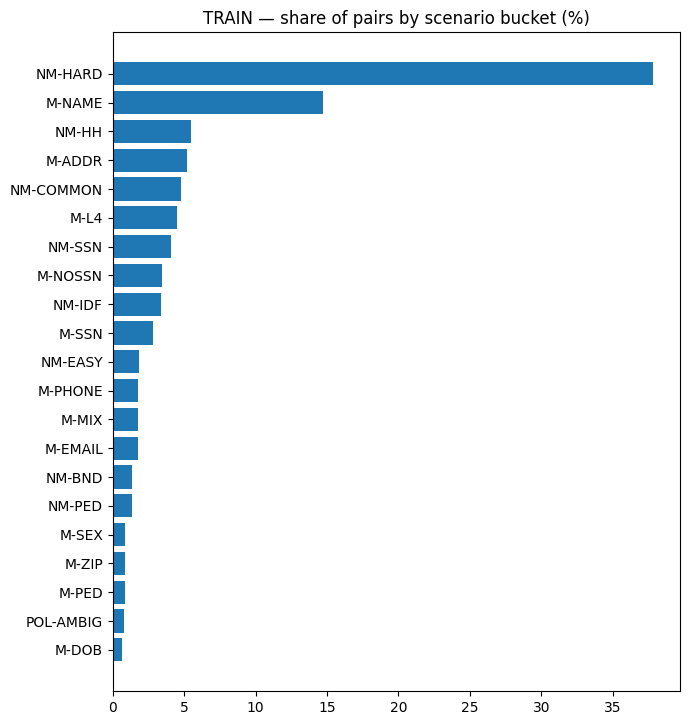

In [6]:
# Bucket bar chart (train)
b = train['case_type'].map(bucket).value_counts()
barh((b/len(train)*100).rename('pct'), 'TRAIN — share of pairs by scenario bucket (%)')

## 3. Field presence vs real marginals (±3pp)

Stack both `_l` and `_r` sides of every pair and compare per-field presence to the measured real marginals
from `synthetic_data_stats.json`. The redesign's key fix was *not* over-populating fields via forced `ensure_*`.

> **Note:** `SSN_clean` is *intentionally* suppressed below the real 21.4% — the §8.4 design makes ~80% of
> positives have no usable SSN match, so SSN presence in the corpus is lower than the population marginal by design.

In [7]:
def real_presence(base):
    # pull the real present-rate from the stats json where available
    if base in stats['missingness']:
        return 1 - stats['missingness'][base]['pct_missing']
    if base == 'SSN_clean':   return stats['ssn']['pct_nonnull_full_ssn']
    if base == 'last_4_SSN':  return stats['ssn']['pct_nonnull_last4']
    if base == 'Phones_set':  return 1 - stats['phones']['Phone03NBR_clean'].get('pct_nonnull', 0)*0  # handled below
    return None

rows = []
for base in MODEL_BASES:
    if base == 'Phones_set':
        # presence of >=1 phone: any phone slot non-null on real side; spec target ~94.4%
        real = 0.944
    else:
        real = real_presence(base)
    stacked = pd.concat([train[f'{base}_l'], train[f'{base}_r']])
    syn = present(stacked).mean()
    if real is None:
        rows.append((base, syn, np.nan, np.nan, ''))
    else:
        d = (syn - real) * 100
        flag = 'OK' if abs(d) <= 3 else ('by-design' if base == 'SSN_clean' else 'OFF >3pp')
        rows.append((base, syn, real, d, flag))
pres = pd.DataFrame(rows, columns=['field','synthetic','real','delta_pp','status']).set_index('field')
pres = pres.round({'synthetic':3,'real':3,'delta_pp':2})
print(pres.to_string())

                     synthetic   real  delta_pp     status
field                                                     
FirstNM_clean            1.000  0.993      0.73         OK
MiddleNM_clean           0.202  0.194      0.76         OK
LastNM_clean             1.000  0.997      0.32         OK
SuffixNM_clean           0.012  0.002      1.00         OK
BirthDT_clean            0.999  0.997      0.21         OK
SSN_clean                0.139  0.214     -7.49  by-design
last_4_SSN               0.335  0.357     -2.19         OK
SexAtBirthDSC_clean      0.796  0.791      0.58         OK
AddressLine1_clean       0.962  0.963     -0.12         OK
AddressLine2_clean       0.308  0.294      1.40         OK
CityNM_clean             0.962  0.974     -1.25         OK
StateCD_clean            0.962  0.972     -0.99         OK
ZipCD_clean_base         0.962  0.972     -0.99         OK
Phones_set               0.942  0.944     -0.15         OK
Email_clean              0.295  0.311     -1.64         

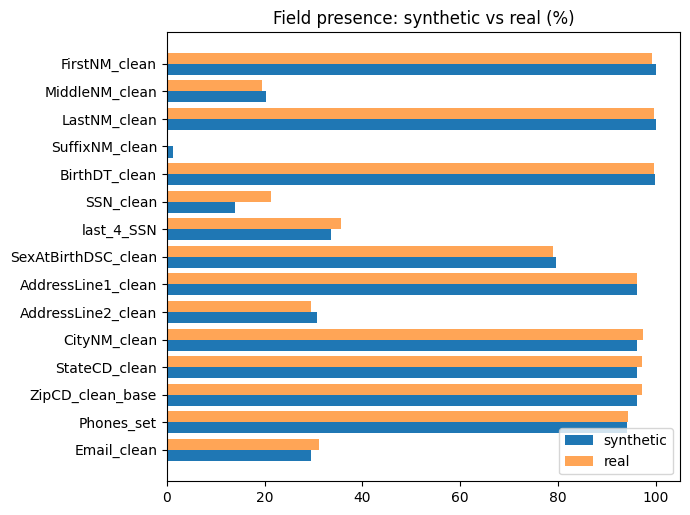

In [8]:
# overlay chart: synthetic vs real presence
have_real = pres.dropna(subset=['real'])
ser = (have_real['synthetic']*100).rename('pct')
realmap = (have_real['real']*100).to_dict()
barh(ser, 'Field presence: synthetic vs real (%)', real=realmap)

## 4. Value distributions vs real (state, sex, DOB decade, email domain, SSN band)

STATE (top 8):
    synthetic   real
AZ        NaN   0.01
CA       0.50   0.88
CO        NaN   0.04
FL        NaN   0.04
GA        NaN   0.02
HI       2.70   3.42
IA        NaN   0.02
IL      85.33  81.11


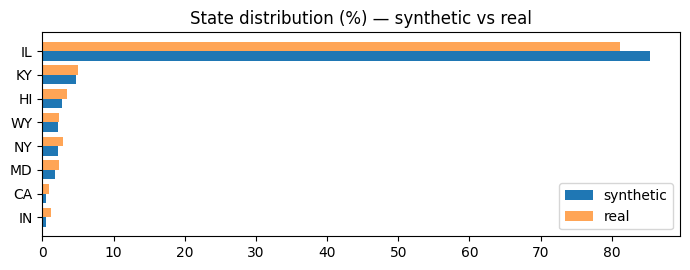

In [9]:
# --- State (present rows, stacked) ---
st = pd.concat([train.StateCD_clean_l, train.StateCD_clean_r])
st = st[present(st)]
syn_state = (st.value_counts(normalize=True)*100).head(8)
tot = sum(stats['categorical_top']['StateCD_clean']['top'].values())
real_state = {k: v/tot*100 for k, v in stats['categorical_top']['StateCD_clean']['top'].items()}
cmp = pd.DataFrame({'synthetic': syn_state.round(2), 'real': pd.Series(real_state).round(2)}).head(8)
print('STATE (top 8):'); print(cmp.to_string())
barh(syn_state.rename('pct'), 'State distribution (%) — synthetic vs real', real=real_state, top=8)

In [10]:
# --- Sex (present rows) ---
sx = pd.concat([train.SexAtBirthDSC_clean_l, train.SexAtBirthDSC_clean_r])
sx = sx[present(sx)]
syn_sex = (sx.value_counts(normalize=True)*100)
tot = sum(stats['categorical_top']['SexAtBirthDSC_clean']['top'].values())
real_sex = {k: v/tot*100 for k, v in stats['categorical_top']['SexAtBirthDSC_clean']['top'].items()}
print('SEX (among present):')
print(pd.DataFrame({'synthetic': syn_sex.round(2), 'real': pd.Series(real_sex).round(2)}).to_string())

SEX (among present):
        synthetic   real
FEMALE      53.95  55.51
MALE        45.26  44.20
OTHER        0.79   0.29


In [11]:
# --- DOB decade ---
dob = pd.concat([train.BirthDT_clean_l, train.BirthDT_clean_r])
dob = dob[present(dob)]
dec = (pd.to_datetime(dob, errors='coerce').dt.year // 10 * 10)
syn_dec = (dec.value_counts(normalize=True).sort_index()*100)
rh = stats['dob']['decade_histogram']; rtot = sum(rh.values())
real_dec = {int(k): v/rtot*100 for k, v in rh.items()}
cmp = pd.DataFrame({'synthetic': syn_dec.round(2), 'real': pd.Series(real_dec).round(2)}).fillna(0)
print('DOB decade (%):'); print(cmp.to_string())
pct2000 = dec[dec>=2000].count()/len(dec)*100
print(f'\nyear>=2000 share: synthetic {pct2000:.1f}% | real {stats["dob"]["pct_year_2000_plus"]*100:.1f}% (pediatric+young-adult)')

DOB decade (%):
      synthetic   real
1900       0.01   0.00
1910       0.08   0.05
1920       0.19   0.18
1930       0.72   0.74
1940       2.43   2.39
1950       7.09   7.19
1960      10.89  11.18
1970      12.88  13.33
1980      17.98  18.22
1990      18.77  19.73
2000      14.14  14.51
2010      11.71  10.03
2020       3.13   2.45
2030       0.00   0.00

year>=2000 share: synthetic 29.0% | real 27.0% (pediatric+young-adult)


In [12]:
# --- Email domain (among present) ---
em = pd.concat([train.Email_clean_l, train.Email_clean_r])
em = em[present(em)].astype(str).str.split('@').str[-1]
syn_dom = (em.value_counts(normalize=True)*100).head(6)
rd = stats['email']['top_domains']; rtot = sum(rd.values())
real_dom = {k: v/rtot*100 for k, v in rd.items()}
print('EMAIL domain (top 6, among present):')
print(pd.DataFrame({'synthetic': syn_dom.round(2), 'real': pd.Series(real_dom).round(2)}).head(6).to_string())
print(f'gmail share — synthetic {syn_dom.get("gmail.com",0):.1f}% | real {real_dom.get("gmail.com",0):.1f}%')

EMAIL domain (top 6, among present):
             synthetic  real
aol.com           0.98  0.92
att.net            NaN  0.31
comcast.net        NaN  0.30
cps.edu            NaN  0.50
gamil.com          NaN  0.13
gmai.com          0.88  0.07
gmail share — synthetic 67.9% | real 68.5%


In [13]:
# --- SSN band per record (stacked): full / last4-only / none ---
def ssn_band_counts(df):
    full_l = present(df.SSN_clean_l); full_r = present(df.SSN_clean_r)
    l4_l = present(df.last_4_SSN_l); l4_r = present(df.last_4_SSN_r)
    full = pd.concat([full_l, full_r]); l4 = pd.concat([l4_l, l4_r])
    band = np.where(full, 'full', np.where(l4, 'last4_only', 'none'))
    return pd.Series(band).value_counts(normalize=True)*100
print('SSN band per record (stacked, %):')
print(ssn_band_counts(train).round(2).to_string())
print('\nReal population (spec §5.1): full 21.4% / last4-only 14.3% / none 64.3%')
print('Corpus suppresses full-SSN by design (§8.4: ~80% of positives carry no usable SSN match).')

SSN band per record (stacked, %):


none          66.40
last4_only    19.71
full          13.89

Real population (spec §5.1): full 21.4% / last4-only 14.3% / none 64.3%
Corpus suppresses full-SSN by design (§8.4: ~80% of positives carry no usable SSN match).


## 5. Positives — anchor survival & difficulty

**Anchor survival** is the v0.6 invariant: *every* positive must retain at least one surviving strong signal
(matching SSN, last-4, address, phone-overlap, or name+DOB). This is what makes a positive human-agreeable.
It should be ~100%.

In [14]:
pos = train[train.label == 1].copy()
ssn_eq = both_eq(pos, 'SSN_clean')
l4_eq = both_eq(pos, 'last_4_SSN')
addr_eq = both_eq(pos, 'AddressLine1_clean')
phn_ov = phone_overlap(pos)
# near name+dob: token-set overlap on names AND equal DOB
def tok_overlap(df):
    def ov(row):
        a = set(str(row['full_name_tokens_l']).split()); b = set(str(row['full_name_tokens_r']).split())
        a.discard(''); b.discard('')
        return len(a & b) > 0
    return df.apply(ov, axis=1)
name_dob = (both_eq(pos,'full_name_compact') | tok_overlap(pos)) & both_eq(pos,'BirthDT_clean')
anchor = ssn_eq | l4_eq | addr_eq | phn_ov | name_dob
print(f'positives: {len(pos)}')
for nm, mask in [('ssn match', ssn_eq), ('last-4 match', l4_eq), ('address match', addr_eq),
                 ('phone overlap', phn_ov), ('name+DOB', name_dob), ('ANY ANCHOR', anchor)]:
    print(f'  {nm:16s} {mask.mean():.4f}')
no_anchor = pos[~anchor]
print(f'\nNO-ANCHOR positives: {len(no_anchor)} ({len(no_anchor)/len(pos):.2%}) — should be ~0')
if len(no_anchor):
    print(no_anchor.case_type.value_counts().head(10).to_string())

positives: 16000
  ssn match        0.0500
  last-4 match     0.2000
  address match    0.2914
  phone overlap    0.8582
  name+DOB         0.9354
  ANY ANCHOR       1.0000

NO-ANCHOR positives: 0 (0.00%) — should be ~0


Differing-field count per positive:
1    5107
2    6203
3    2728
4    1391
5     467
6      78
7      24
8       2

mean 2.14 | median 2 (spec §12.8 target mean ~2-3, real spread, no 1-corruption spike)


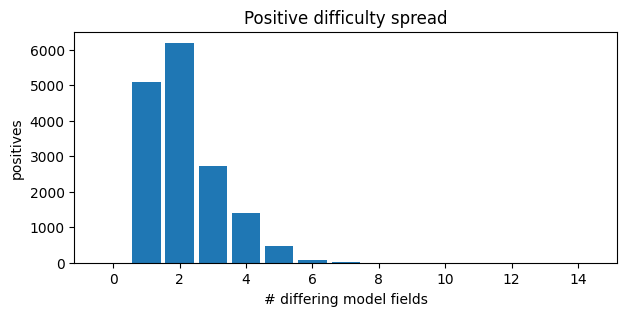

In [15]:
# Difficulty: how many of the 15 model fields differ between the two sides of a positive?
# Compare on the *serialized* values (what the model sees: phones flattened, dob normalized).
def serialized_sides(df):
    p = prep_paired_df(df.reset_index(drop=True))
    friendly = list(CANONICAL_RENAMES.values())
    L = p[[f'{f}_l' for f in friendly]].fillna('').astype(str).values
    R = p[[f'{f}_r' for f in friendly]].fillna('').astype(str).values
    return (L != R).sum(axis=1)
pos_diff = serialized_sides(pos)
print('Differing-field count per positive:')
print(pd.Series(pos_diff).value_counts().sort_index().to_string())
print(f'\nmean {pos_diff.mean():.2f} | median {np.median(pos_diff):.0f} (spec §12.8 target mean ~2-3, real spread, no 1-corruption spike)')
if HAVE_PLT:
    plt.figure(figsize=(7,3)); plt.hist(pos_diff, bins=range(0,16), align='left', rwidth=0.85)
    plt.xlabel('# differing model fields'); plt.ylabel('positives'); plt.title('Positive difficulty spread'); plt.show()

In [16]:
# SSN-band shares of positives (target 5% full / 15% last4 / 80% no-usable-SSN) and address-match rate.
def usable_ssn(df):
    full = both_eq(df, 'SSN_clean')
    l4 = both_eq(df, 'last_4_SSN')
    return full, l4
full, l4 = usable_ssn(pos)
hard = ~(full | l4)
print(f'positives full-SSN match : {full.mean():.1%}  (target <=5%)')
print(f'positives last-4 match   : {l4.mean():.1%}  (target ~15%)')
print(f'positives no usable SSN  : {hard.mean():.1%}  (target ~80%)')
print(f'positives address match  : {both_eq(pos,"AddressLine1_clean").mean():.1%}  (target ~25-30%, real line1_exact 28.8%)')

positives full-SSN match : 5.0%  (target <=5%)
positives last-4 match   : 20.0%  (target ~15%)
positives no usable SSN  : 80.0%  (target ~80%)
positives address match  : 29.1%  (target ~25-30%, real line1_exact 28.8%)


## 6. Negatives — hardness & label integrity

Negatives should be **blocking-survivor-like** (share ≥1 strong key), not random strangers. Critically, no
negative should carry the **POL-AMBIG-03 match signature** (`first + last + DOB + address` all equal with no SSN) —
that combination is labeled match=1 elsewhere, so labeling it 0 would be a direct contradiction.

In [17]:
neg = train[train.label == 0].copy()
STRONG = ['LastNM_clean', 'BirthDT_clean', 'AddressLine1_clean', 'last_4_SSN', 'Phones_set']
def shared_strong_count(df):
    cnt = np.zeros(len(df), dtype=int)
    for base in STRONG:
        if base == 'Phones_set':
            cnt = cnt + phone_overlap(df).values.astype(int)
        else:
            cnt = cnt + both_eq(df, base).values.astype(int)
    return cnt
nshare = shared_strong_count(neg)
print('negatives by # shared strong keys:')
print(pd.Series(nshare).value_counts().sort_index().to_string())
print(f'\nshare >=1 key: {(nshare>=1).mean():.1%} | share >=2: {(nshare>=2).mean():.1%} (target ~35-40%)')
print(f'share 0 keys (random-ish): {(nshare==0).mean():.1%} (train keeps a ~3% easy anchor)')

negatives by # shared strong keys:
0     1506
1    13331
2     6712
3     2446
4        5

share >=1 key: 93.7% | share >=2: 38.2% (target ~35-40%)
share 0 keys (random-ish): 6.3% (train keeps a ~3% easy anchor)


In [18]:
# LABEL CONTRADICTION CHECK — the fix from this review.
def match_signature(df):
    return (both_eq(df,'FirstNM_clean') & both_eq(df,'LastNM_clean') &
            both_eq(df,'BirthDT_clean') & both_eq(df,'AddressLine1_clean') &
            ~both_eq(df,'SSN_clean') & ~both_eq(df,'last_4_SSN'))
for name, df in [('TRAIN', train), ('TEST', test)]:
    ng = df[df.label==0]
    bad = match_signature(ng)
    print(f'{name}: negatives with first+last+DOB+addr all equal & no SSN = {int(bad.sum())} '
          f'({bad.mean():.3%} of negs)')
    if bad.sum():
        print('   ', ng[bad].case_type.value_counts().head(5).to_dict())
print('\n(Was 384 in train before the force_shared_keys fix; residual few are coincidental same-top-N first names.)')

TRAIN: negatives with first+last+DOB+addr all equal & no SSN = 15 (0.062% of negs)


    {'NM-HARD-ADDR+DOB+LASTNAME': 8, 'NM-HH-JR-SR': 7}
TEST: negatives with first+last+DOB+addr all equal & no SSN = 7 (0.088% of negs)
    {'NM-HARD-ADDR+DOB+LASTNAME': 6, 'NM-HH-JR-SR': 1}

(Was 384 in train before the force_shared_keys fix; residual few are coincidental same-top-N first names.)


In [19]:
# Test set must be ALL-hard (>=1 shared key) so precision is measured honestly.
te_neg = test[test.label==0]
cov = (shared_strong_count(te_neg) >= 1).mean()
print(f'TEST negatives sharing >=1 strong key: {cov:.1%} (spec §12.9 target >=95%)')

TEST negatives sharing >=1 strong key: 96.6% (spec §12.9 target >=95%)


## 7. Name-coupling token-set invariance

For the pure name-*shuffle* scenarios (tokens move between First/Middle/Last but the set is unchanged),
`full_name_tokens` must be identical on both sides — otherwise the derived token signal is broken.

In [20]:
# Pure shuffles (tokens move slots but the SET is unchanged): first<->middle swap,
# two-surname shuffle, name-order swap. NOTE: M-NAME-04 is a two-surname *collapse*
# (drops a surname token) so it is intentionally NOT token-preserving and excluded here.
SHUFFLE_CASES = ['M-NAME-02','M-NAME-03','M-NAME-05']
sh = train[train.case_type.isin(SHUFFLE_CASES)]
inv = (sh.full_name_tokens_l.fillna('') == sh.full_name_tokens_r.fillna('')).mean() if len(sh) else float('nan')
print(f'pure-shuffle pairs: {len(sh)} | full_name_tokens identical: {inv:.1%} (target 100%)')
coll = train[train.case_type=='M-NAME-04']
coll_inv = (coll.full_name_tokens_l.fillna('') == coll.full_name_tokens_r.fillna('')).mean()
print(f'(sanity) M-NAME-04 collapse: {len(coll)} pairs, token-identical {coll_inv:.1%} — expected LOW (a token is dropped)')
print('\nExamples (first/middle/last on each side):')
cols = ['case_type','FirstNM_clean_l','MiddleNM_clean_l','LastNM_clean_l',
        'FirstNM_clean_r','MiddleNM_clean_r','LastNM_clean_r']
print(sh[cols].head(8).to_string(index=False))

pure-shuffle pairs: 1041 | full_name_tokens identical: 100.0% (target 100%)
(sanity) M-NAME-04 collapse: 347 pairs, token-identical 2.6% — expected LOW (a token is dropped)

Examples (first/middle/last on each side):
case_type FirstNM_clean_l MiddleNM_clean_l LastNM_clean_l FirstNM_clean_r MiddleNM_clean_r LastNM_clean_r
M-NAME-03         MICHAEL           ZAMORA          JONES         MICHAEL                    ZAMORA JONES
M-NAME-02          VICTOR      CHRISTOPHER         GARCIA     CHRISTOPHER           VICTOR         GARCIA
M-NAME-02            JOHN          EDUARDO   ZAVALA BROWN         EDUARDO             JOHN   ZAVALA BROWN
M-NAME-03          SANDRA            MOORE        SALGADO          SANDRA                   MOORE SALGADO
M-NAME-05        VAN HUNG                              VO              VO                        VAN HUNG
M-NAME-02            ROSA        ELIZABETH         TORRES       ELIZABETH             ROSA         TORRES
M-NAME-02         LEILANI           KEISH

In [21]:
# Vietnamese name diversity (fix #2 — was a single hardcoded pair).
v = train[train.case_type=='M-NAME-05']
combos = (v.FirstNM_clean_l + '|' + v.LastNM_clean_l).nunique()
print(f'M-NAME-05: {len(v)} pairs, {combos} distinct (first|last) combos')

M-NAME-05: 347 pairs, 156 distinct (first|last) combos


## 8. Entity disjointness & duplicate-pair leakage

In [22]:
train_ents = set(train.entity_id_a) | set(train.entity_id_b)
test_ents  = set(test.entity_id_a)  | set(test.entity_id_b)
overlap = train_ents & test_ents
print(f'entities — train {len(train_ents)} | test {len(test_ents)} | overlap {len(overlap)} (must be 0)')

# duplicate identical pairs (same serialized A/B) within a file
def dup_rate(df):
    p = prep_paired_df(df.reset_index(drop=True))
    friendly = list(CANONICAL_RENAMES.values())
    key = p[[f'{f}_l' for f in friendly] + [f'{f}_r' for f in friendly]].astype(str).agg('|'.join, axis=1)
    d = key.duplicated().sum()
    return d, d/len(df)
for name, df in [('TRAIN', train), ('TEST', test)]:
    d, r = dup_rate(df)
    print(f'{name}: exact-duplicate serialized pairs = {d} ({r:.2%})')

entities — train 64000 | test 18000 | overlap 0 (must be 0)


TRAIN: exact-duplicate serialized pairs = 0 (0.00%)
TEST: exact-duplicate serialized pairs = 0 (0.00%)


## 9. Serialized mode4 prompt preview

This is the exact text the GPT-2 mode4 classifier reads (via `prep_paired_df` → `df_serializer`).
Confirm attribute names are the friendly schema, missing values render as `N/A`, and the prompt reads sensibly
for both a positive and a negative of each major bucket.

In [23]:
def show_prompts(df, case_types, n=1):
    sub = df[df.case_type.isin(case_types)]
    rows = []
    for ct in case_types:
        rows.append(sub[sub.case_type==ct].head(n))
    sample = pd.concat(rows) if rows else sub.head(0)
    prepped = prep_paired_df(sample.reset_index(drop=True))
    ser = df_serializer(prepped.copy(), 'mode4')
    for (_, meta), (_, s) in zip(sample.reset_index().iterrows(), ser.iterrows()):
        print('='*100)
        print(f"case_type={meta['case_type']}  label={meta['label']}")
        print(s['text'])
        print()

print('### POSITIVE examples'); show_prompts(train, ['M-SSN-04','M-NAME-03','M-NOSSN-02','M-L4-02','M-MIX-02'])

### POSITIVE examples
case_type=M-SSN-04  label=1
Given the attributes of two records, are they the same? Record A is first_name: MARIA, middle_name: N, last_name: FITZGERALD, suffix: , dob: 2001-10-14, ssn: 617825464, ssn4: 5464, sex: FEMALE, address: 6378 KARLOV ST, address2: , city: CHICAGO, state: IL, zip: 60612, phone: 2248196911 3315135926, email: . Record B is first_name: MARIA, middle_name: N, last_name: SALGADO, suffix: , dob: 2001-10-14, ssn: 617825464, ssn4: 5464, sex: FEMALE, address: 6378 KARLOV ST, address2: , city: CHICAGO, state: IL, zip: 60612, phone: 2248196911 3315135926, email: .

case_type=M-NAME-03  label=1
Given the attributes of two records, are they the same? Record A is first_name: MICHAEL, middle_name: ZAMORA, last_name: JONES, suffix: , dob: 1995-05-19, ssn: , ssn4: , sex: MALE, address: 10912 PETERSON AVE, address2: , city: CHICAGO, state: IL, zip: 60647, phone: 3123265955 3314553075 8152836274, email: . Record B is first_name: MICHAEL, middle_name: , last_

In [24]:
print('### NEGATIVE examples'); show_prompts(train, ['NM-HH-TWIN','NM-HH-JR-SR','NM-SSN-03','NM-IDF-01','NM-COMMON-01'])
print('### Combinatorial hard negative (NM-HARD-*)')
show_prompts(train, [c for c in train.case_type.unique() if c.startswith('NM-HARD')][:2])

### NEGATIVE examples
case_type=NM-HH-TWIN  label=0
Given the attributes of two records, are they the same? Record A is first_name: JESUS, middle_name: , last_name: BROWN, suffix: , dob: 1963-06-09, ssn: , ssn4: , sex: , address: 7815 SHERIDAN ST, address2: APT 1A, city: LOUISVILLE, state: KY, zip: 40299, phone: 2702294142 2709109661, email: . Record B is first_name: MARY, middle_name: , last_name: BROWN, suffix: , dob: 1963-06-09, ssn: , ssn4: , sex: FEMALE, address: 7815 SHERIDAN ST, address2: APT 1A, city: LOUISVILLE, state: KY, zip: 40299, phone: 2245024203 8724181955, email: jenniferanderson68@hotmail.com.

case_type=NM-HH-JR-SR  label=0
Given the attributes of two records, are they the same? Record A is first_name: MARIA, middle_name: , last_name: LOPEZ, suffix: , dob: 1986-12-18, ssn: 532096593, ssn4: 6593, sex: FEMALE, address: 1994 63RD AVE, address2: , city: HONOKAA, state: HI, zip: 96711, phone: 8082263558 8083628672, email: maria.lopez@gmail.com. Record B is first_name: MAR

## 9.5 Name↔sex consistency & surname-change realism

Two joint-distribution checks: (1) a record's first name should match its sex (no JOSE/FEMALE);
(2) a full surname *replacement* (maiden→married) should be female — men keep only gender-neutral
typo/dropped-surname changes.

In [25]:
import sys
if 'synthetic_data_generation' not in sys.path:
    sys.path.insert(0, 'synthetic_data_generation')
from generate_synthetic import name_gender

# (1) name<->sex agreement among gendered names with a present sex (stacked sides)
_recs = []
for _s in ('l', 'r'):
    _d = train[[f'FirstNM_clean_{_s}', f'SexAtBirthDSC_clean_{_s}', 'label']].copy()
    _d.columns = ['first', 'sex', 'label']; _recs.append(_d)
_rec = pd.concat(_recs, ignore_index=True)
_rec['g'] = _rec['first'].map(name_gender)
_m = _rec[(_rec.sex.isin(['MALE', 'FEMALE'])) & (_rec.g.notna())]
name_sex_agree = (_m.g == _m.sex).mean()
_mp = _m[_m.label == 1]
print(f'name<->sex agreement: {name_sex_agree:.2%} overall | {(_mp.g==_mp.sex).mean():.2%} on positives')
print('  (residual is the intended ~1.5% sex-flip clerical-error signal on hard negatives)')

# (2) surname full-replacement (maiden->married) by sex, from the corruptions_applied tag
import json as _json
_pos = train[train.label == 1].copy()
_pos['corr'] = _pos['corruptions_applied'].apply(lambda s: _json.loads(s) if s else [])
def _sex_of(df):
    return df['SexAtBirthDSC_clean_l'].where(df['SexAtBirthDSC_clean_l'].str.len() > 0,
                                             df['SexAtBirthDSC_clean_r'])
_rl = _pos[_pos['corr'].apply(lambda c: 'replace_last' in c)]
_sx = _sex_of(_rl); _mf = _sx[_sx.isin(['MALE', 'FEMALE'])]
surname_female_pct = (_mf == 'FEMALE').mean() if len(_mf) else float('nan')
print(f"\nmaiden->married 'replace_last': {len(_rl)} pairs | FEMALE {surname_female_pct:.1%} / MALE {(_mf=='MALE').mean():.1%}")
_tl = _pos[_pos['corr'].apply(lambda c: 'typo_last' in c)]
_sx2 = _sex_of(_tl); _mf2 = _sx2[_sx2.isin(['MALE', 'FEMALE'])]
print(f"gender-neutral 'typo_last':    {len(_tl)} pairs | FEMALE {(_mf2=='FEMALE').mean():.1%} / MALE {(_mf2=='MALE').mean():.1%} (stays balanced)")


name<->sex agreement: 99.44% overall | 100.00% on positives
  (residual is the intended ~1.5% sex-flip clerical-error signal on hard negatives)

maiden->married 'replace_last': 67 pairs | FEMALE 100.0% / MALE 0.0%
gender-neutral 'typo_last':    3244 pairs | FEMALE 55.1% / MALE 44.9% (stays balanced)


## 10. Summary dashboard

In [26]:
checks = []
def chk(name, ok, detail=''):
    checks.append((('PASS' if ok else 'FAIL'), name, detail))

# recompute the headline numbers compactly
m_tr = train.label.mean(); m_te = test.label.mean()
chk('train balance ~40% match', abs(m_tr-0.40) < 0.03, f'{m_tr:.1%}')
chk('test prevalence ~20% match', abs(m_te-0.20) < 0.03, f'{m_te:.1%}')
chk('every train case_type present in test', len(missing_in_test)==0, f'{len(missing_in_test)} missing')
pres_off = pres[(pres.status=='OFF >3pp')]
chk('field presence within +/-3pp (ex. SSN by-design)', len(pres_off)==0, f'{list(pres_off.index)}')
chk('positive anchor survival ~100%', (~anchor).sum() <= 0.01*len(pos), f'{(~anchor).mean():.2%} no-anchor')
chk('positive no-usable-SSN ~80%', abs(hard.mean()-0.80) < 0.05, f'{hard.mean():.1%}')
chk('positive difficulty mean 2-3 fields', 1.5 <= pos_diff.mean() <= 3.5, f'{pos_diff.mean():.2f}')
bad_tr = match_signature(train[train.label==0]).sum()
chk('no match/non-match contradiction', bad_tr < 0.005*len(neg), f'{int(bad_tr)} contradictory negs')
chk('test negatives >=1 strong key (>=95%)', cov >= 0.95, f'{cov:.1%}')
chk('name-shuffle token invariance 100%', inv == 1.0, f'{inv:.1%}')
chk('entity-disjoint train/test', len(overlap)==0, f'{len(overlap)} overlap')

chk('name<->sex agreement >=99%', name_sex_agree >= 0.99, f'{name_sex_agree:.2%}')
chk('surname replacement female-only', surname_female_pct >= 0.95, f'{surname_female_pct:.0%} female')
dash = pd.DataFrame(checks, columns=['status','check','detail'])
print(dash.to_string(index=False))
n_fail = (dash.status=='FAIL').sum()
print('\n' + ('ALL CHECKS PASS — corpus looks good for fine-tuning.' if n_fail==0 else f'{n_fail} CHECK(S) FAILED — investigate above.'))

status                                            check                detail
  PASS                         train balance ~40% match                 40.0%
  PASS                       test prevalence ~20% match                 20.0%
  PASS            every train case_type present in test             0 missing
  PASS field presence within +/-3pp (ex. SSN by-design)                    []
  PASS                   positive anchor survival ~100%       0.00% no-anchor
  PASS                      positive no-usable-SSN ~80%                 80.0%
  PASS              positive difficulty mean 2-3 fields                  2.14
  PASS                 no match/non-match contradiction 15 contradictory negs
  PASS            test negatives >=1 strong key (>=95%)                 96.6%
  PASS               name-shuffle token invariance 100%                100.0%
  PASS                       entity-disjoint train/test             0 overlap
  PASS                       name<->sex agreement >=99%         



ALL CHECKS PASS — corpus looks good for fine-tuning.
